In [1]:
import os
import cv2
import numpy as np
from lerobot.common.datasets.lerobot_dataset import LEROBOT_HOME
from lerobot.common.datasets.lerobot_dataset import LeRobotDataset
import ffmpeg
import ipdb
import torch
import tqdm
import matplotlib.pyplot as plt
from random import sample 
def plot_robot_xyplane_stats(action_points, state_points):
    points_np = action_points.numpy()[...,:2]
    points_np2 = state_points.numpy()[...,:2]
    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(points_np[:, 0], points_np[:, 1],
                s=2,               # dot size
                c='red',          # dot color
                alpha=.1)        # transparency to emphasize density
    plt.scatter(points_np[:, 0], points_np[:, 1],
                s=2,               # dot size
                c='blue',          # dot color
                alpha=.1)        # transparency to emphasize density
    plt.title('Robot eef on XY plane')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.axis('equal')
    plt.grid(True)
    plt.show()
    # plt.savefig(f'/root/PI_Official/data/visualization/{save_name}.png', dpi=300, bbox_inches='tight')

def cal_cmd_vel(cmd_eef_pos, delta = 3):
    diff = cmd_eef_pos[delta:] - cmd_eef_pos[:-delta]
    return np.sqrt(np.sum(diff*diff, axis=1)).mean()

def cal_cmd_state_diff(action_points, state_points):
    action_points = action_points.numpy()
    state_points = state_points.numpy()
    diff = action_points - state_points
    return np.sqrt(np.sum(diff*diff, axis=1))

In [4]:
repo_id='MultiTask_7task_0422'
sample_num = 20_000

dataset = LeRobotDataset(repo_id, local_files_only=True)
action_points = []
state_points = []
for i in tqdm.tqdm(sample(range(len(dataset)),sample_num)):

    item = dataset[i]
    action_points.append(item['actions'][:3])
    action_points.append(item['actions'][7:10])
    state_points.append(item['observation.state'][:3])
    state_points.append(item['observation.state'][7:10])

action_points = torch.stack(action_points)
state_points = torch.stack(state_points)

Returning existing local_dir `/pfstem/likaiyu/resources/lerobot/MultiTask_7task_0422` as remote repo cannot be accessed in `snapshot_download` (None).
Returning existing local_dir `/pfstem/likaiyu/resources/lerobot/MultiTask_7task_0422` as remote repo cannot be accessed in `snapshot_download` (None).


Resolving data files:   0%|          | 0/5400 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/1164 [00:00<?, ?it/s]

100%|██████████| 20000/20000 [07:32<00:00, 44.23it/s]


In [3]:
plot_robot_xyplane_stats(action_points, state_points)

NameError: name 'action_points' is not defined

In [ ]:
cmd_state_diff = cal_cmd_state_diff(action_points, state_points)
cmd_state_diff.mean()

np.float32(0.015470485)

In [13]:
repo_id='YC_PutPlateOnRack_Rjoints_0516'
sample_num = 10_000

dataset = LeRobotDataset(repo_id, local_files_only=True)
action_points = []
state_points = []
for i in tqdm.tqdm(sample(range(len(dataset)),sample_num)):

    item = dataset[i]
    action_points.append(item['actions'][2:])
    state_points.append(item['observation.state'][2:])

action_points = torch.stack(action_points)
state_points = torch.stack(state_points)

Returning existing local_dir `/pfstem/likaiyu/resources/lerobot/YC_PutPlateOnRack_Rjoints_0516` as remote repo cannot be accessed in `snapshot_download` (None).
Returning existing local_dir `/pfstem/likaiyu/resources/lerobot/YC_PutPlateOnRack_Rjoints_0516` as remote repo cannot be accessed in `snapshot_download` (None).


Resolving data files:   0%|          | 0/4131 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/536 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [01:04<00:00, 154.44it/s]


In [55]:
def plot_angle_limit_violation(state_points, threshold = 5):
    left_angle_limit = [
    [-180,60],[-180,3],[-175,175],[-129,90],[-175,175],[-95,95],[-90,90]
    ]
    right_angle_limit = [
        [-60,180],[-180,3],[-175,175],[-90,129],[-175,175],[-95,95],[-90,90]
    ]
    joint_names = [f'LJ{i}' for i in range(1,8)] + [f'RJ{i}' for i in range(1,8)]
    left_angle_limit = np.array(left_angle_limit)
    right_angle_limit = np.array(right_angle_limit)
    angle_limit = np.concatenate([left_angle_limit,right_angle_limit])

    state_points = 180 * state_points/np.pi
    state_points = state_points.numpy()
    up_violation = np.sum(np.int8(state_points >= angle_limit[:,1]-threshold),axis=0)
    down_violation = np.sum(np.int8(state_points <= angle_limit[:,0]+threshold),axis=0)
    plt.figure(figsize=(8, 6))
    plt.bar(joint_names, up_violation,color='skyblue',alpha=.5)
    plt.bar(joint_names, down_violation,color='yellow',alpha=.5)
                    
    plt.title('Angle Limit Violation By Joint')
    # plt.xlabel('X')
    plt.ylabel('Times of Violation')
    plt.show()

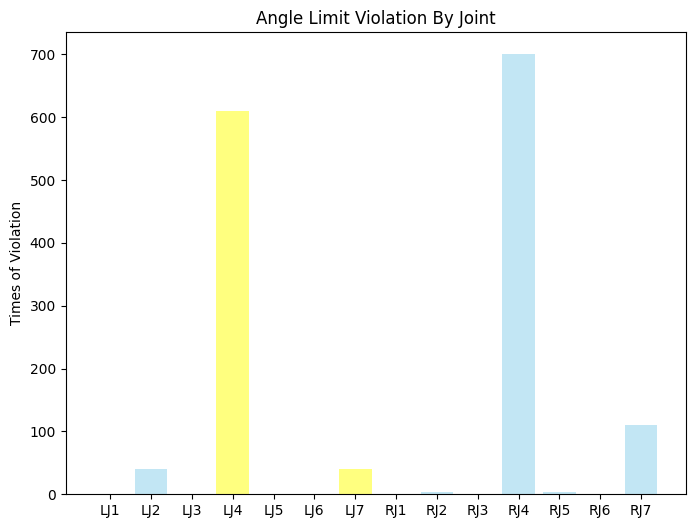

In [56]:
plot_angle_limit_violation(state_points)

In [35]:
len(state_points)

10000